# Multi input Graph

In [18]:
#Our first LangGraph Graph
from typing import Dict, TypedDict, List
from langgraph.graph import StateGraph

In [19]:
class AgentState(TypedDict):
  values : List[int]
  name : str
  result : str

def process_values(state: AgentState) -> AgentState:
  """This Function handels multiple diffrent inputs"""

  state["result"] = f"Hi there {state['name']}! You sum = {sum(state['values'])}"

  return state

graph = StateGraph(AgentState)

graph.add_node("Processer", process_values) # Add node by passing it's name and the function it is going to perform
graph.set_entry_point("Processer") # set the starting node
graph.set_finish_point("Processer") # Set the ending node

app = graph.compile() #Compiling the graph

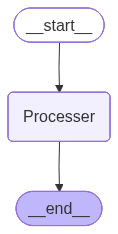

In [20]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [21]:
initialState = {"name":"Bob", "values":[1,2,3,4]}
res = app.invoke(initialState)
print(res)

{'values': [1, 2, 3, 4], 'name': 'Bob', 'result': 'Hi there Bob! You sum = 10'}
